In [12]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [13]:
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 13

In [14]:
## Heat budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer temperature

In [16]:
## Open 5 Day means to compute delta H acrosss the month

catalog = OceanDataCatalog(catalog_name="noc-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to bounding box 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y
              Title: T1y Icechunk repository
              Description: **Annual mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m
              Title: T1m Icechunk repository
              Description: **Monthly mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d
       

In [17]:
dt

<xarray.DataTree>
Group: /
│   Dimensions:               (time_counter: 2555, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 20kB 1990-01-03T12:00...
│       time_centered         (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 41kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 41kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   None
│       iperio:   False
├── Group: /gridT
│       Dimensions:                (time_counter: 2555, j: 37, i: 38, axis_nbounds: 2,
│                                   k: 75)
│       Coordinates:
│           time_centered          (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                      (j) int64 296B 926 927 928 929 ... 959 960 961 962
│         * i                      (i) int64 304B 1011 1012 1013 1014 ... 1046 1047 1048
│         * gphit                  (j, i) float64 11kB 52.07 52.07 52.08 ... 57.98 57.98
│         * glamt                  (j, i) float64 11kB -34.87 -34.6 ... -25.31 -25.03
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/56)
│           berg_latent_heat_flux  (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           friver                 (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           hfds                   (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 11kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           e2t                    (j, i) float64 11kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           top_level              (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           bottom_level           (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           tmask                  (k, j, i) bool 105kB True True True ... False False
│           tmaskutil              (j, i) bool 1kB True True True ... True True True
│       Indexes:
│         ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
│         └ glamt
│       Attributes:
│           nftype:   None
│           iperio:   False
├── Group: /gridU
│       Dimensions:       (j: 1206, i: 1440, k: 75)
│       Coordinates:
│         * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.438e+03 1.44e+03 1.44e+03
│           gphiu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│       Data variables:
│           e1u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           umask         (k, j, i) bool 130MB False False False ... False False False
│           umaskutil     (j, i) bool 2MB False False False False ... False False False
│       Attributes:
│           nftype:   None
│          

In [4]:
# Compute time series of dH/dT

H_ts = (dt.integral(grid='gridT', var='tos_con', dims=['i', 'j'])) * 50 * 1025 * 4000
delta_H = H_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = H_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dHbydt = (delta_H / seconds_in_month).compute()


In [6]:
HC_monthly = H_ts.resample(time_counter = 'ME').mean()
HC_monthly = HC_monthly.compute()

In [7]:
# Save Terms

dHbydt.to_netcdf('dHbydt_50m.nc')
HC_monthly.to_netcdf('HC_50m.nc')

In [3]:
# Start from here 

dHbydt = xr.open_dataset('dHbydt_50m.nc')['__xarray_dataarray_variable__']
Q = xr.open_dataset('Q.nc')['hfds']
integrated_MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']
HC = xr.open_dataset('HC_50m.nc')['tos_con']
SSTs = xr.open_dataset('Integrated_SST_again.nc')['tos_con']
SSTvals = SSTs.values
SSSs = xr.open_dataset('Freshwater Budget/Integrated_SSS.nc')['sos_abs']
SSSvals = SSSs.values

In [4]:
# Calculate advective term and ratios 

advection = dHbydt - Q
magnitude_ratios = abs(Q) / abs(advection)
heatflux_contribution = Q / dHbydt

(-80000000000000.0, 80000000000000.0)

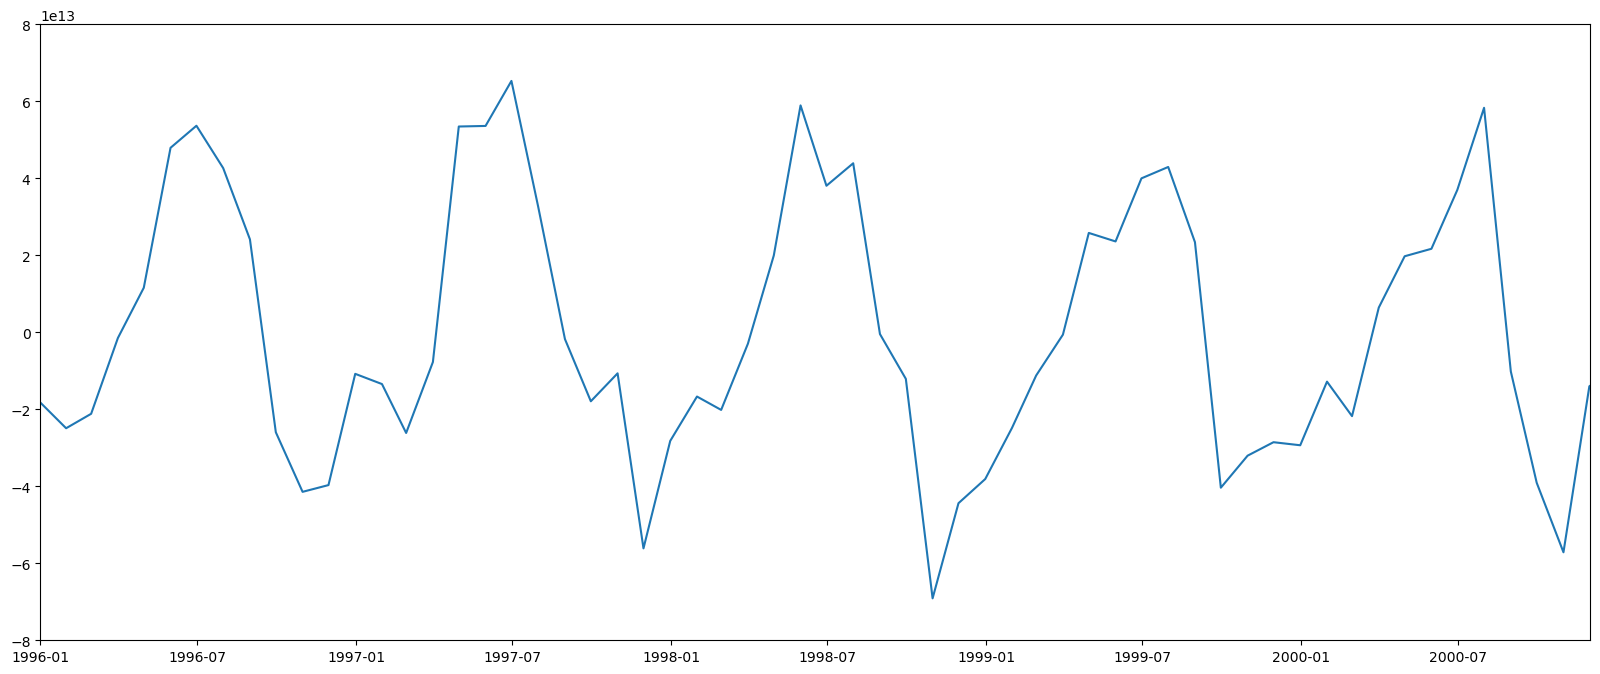

In [5]:
# Change in Heat Content 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(dHbydt['time_counter'], dHbydt)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(-8e13, 8e13)

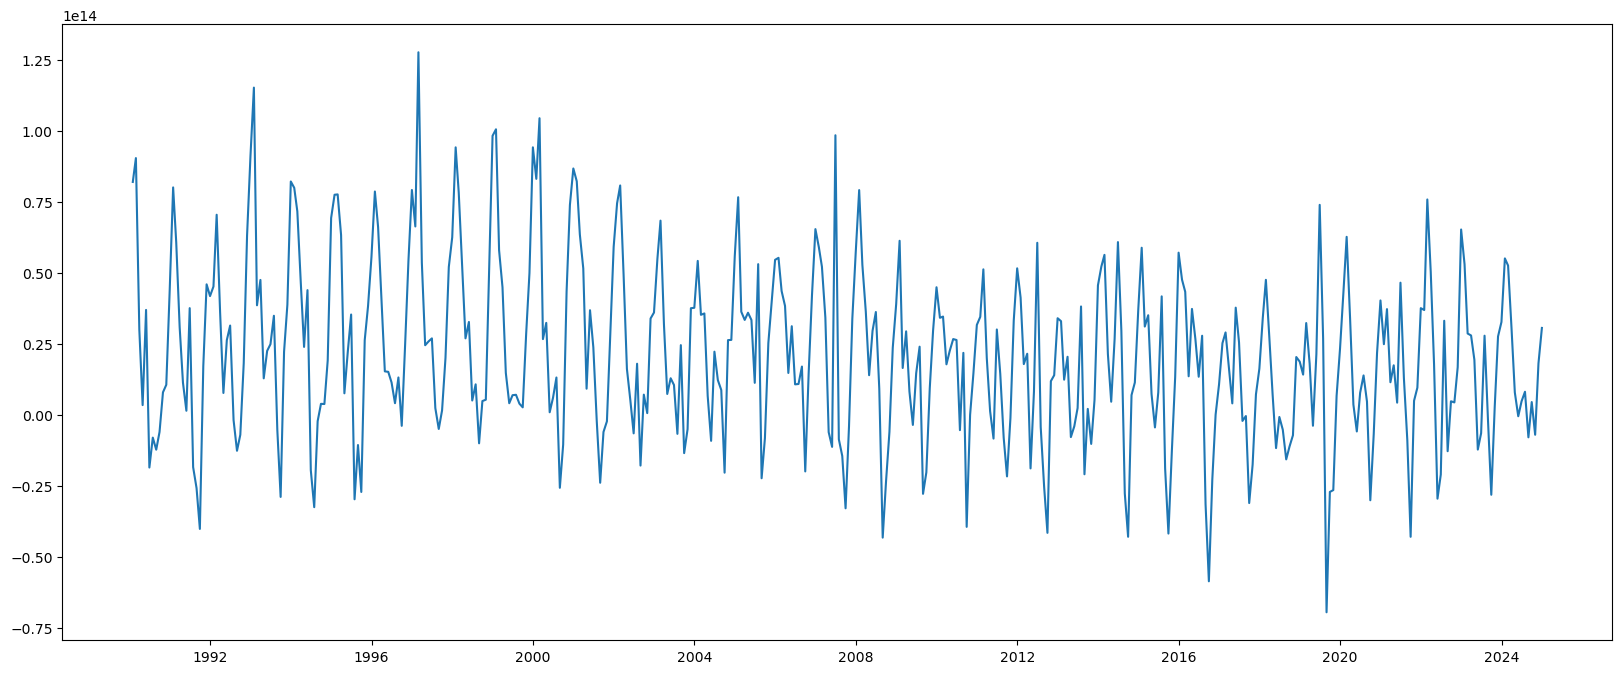

In [6]:
# Plot of advective terms 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(advection['time_counter'], advection)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

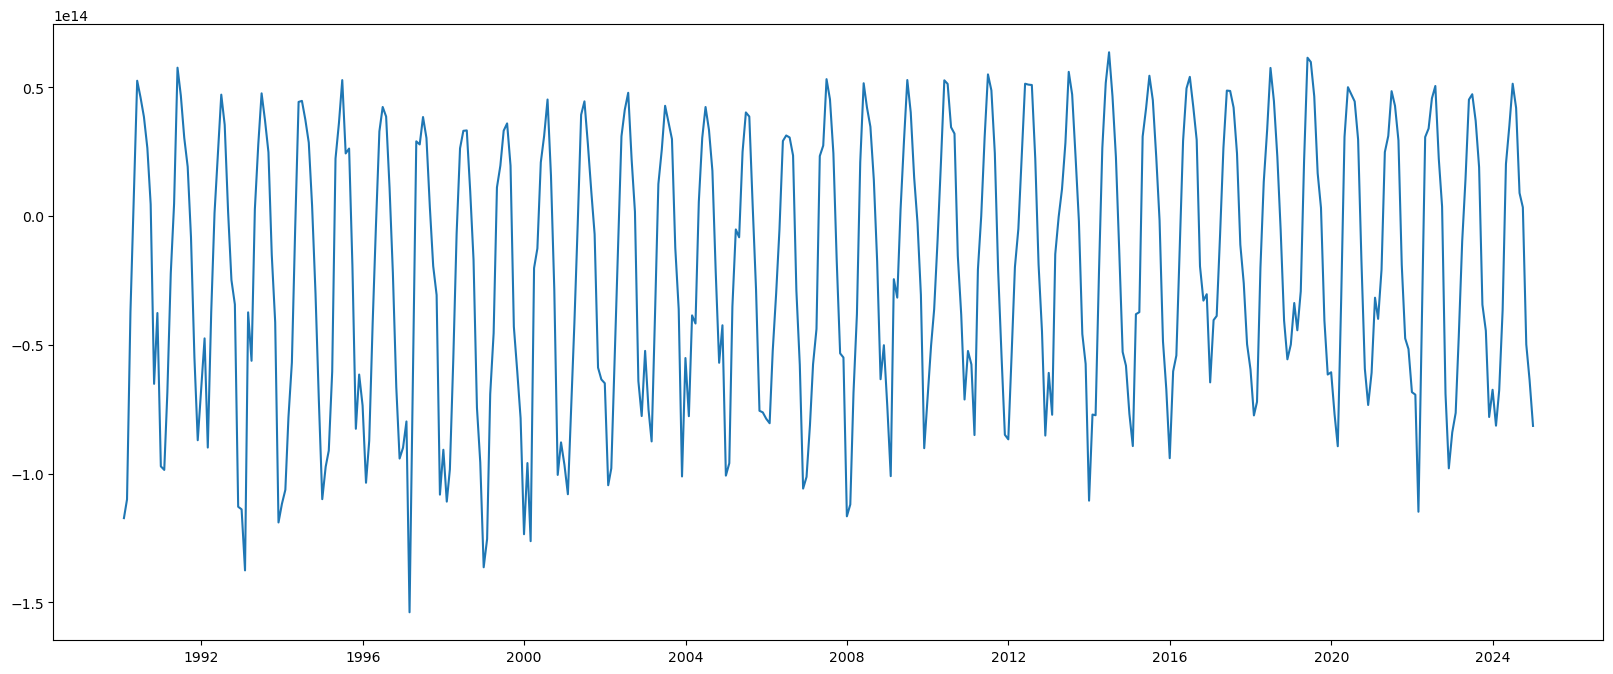

In [7]:
# Surface heat flux terms

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q['time_counter'], Q)
#ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

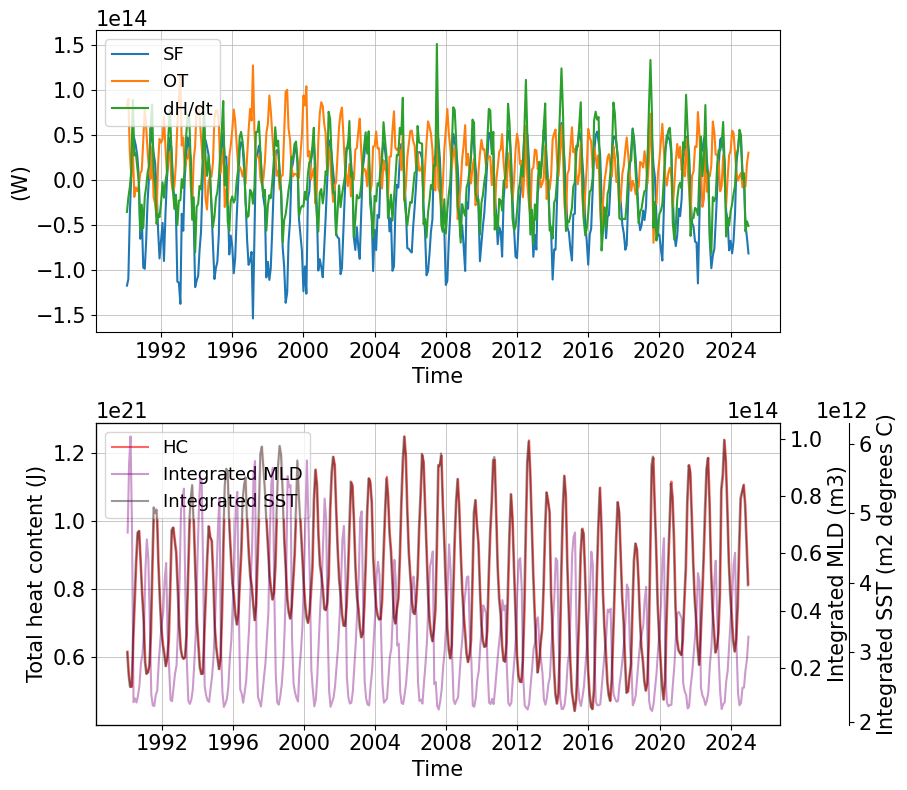

In [50]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(Q['time_counter'], Q, label = 'SF')
ax1.plot(advection['time_counter'], advection, label = 'OT')
ax1.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('(W)')
ax1.grid(True, which='both', linewidth=0.5)

l1 = ax2.plot(HC['time_counter'],HC, label = 'HC', color = 'r', alpha = 0.6)
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple', alpha = 0.4)
l3 = ax4.plot(SSTs['time_counter'], SSTs, label = 'Integrated SST', color = 'k', alpha = 0.4)

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')
ax2.set_ylabel('Total heat content (J)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SST (m2 degrees C)')
ax2.set_xlabel('Time')
ax2.grid(True, which='both', linewidth=0.5)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 

plt.tight_layout()
plt.show()

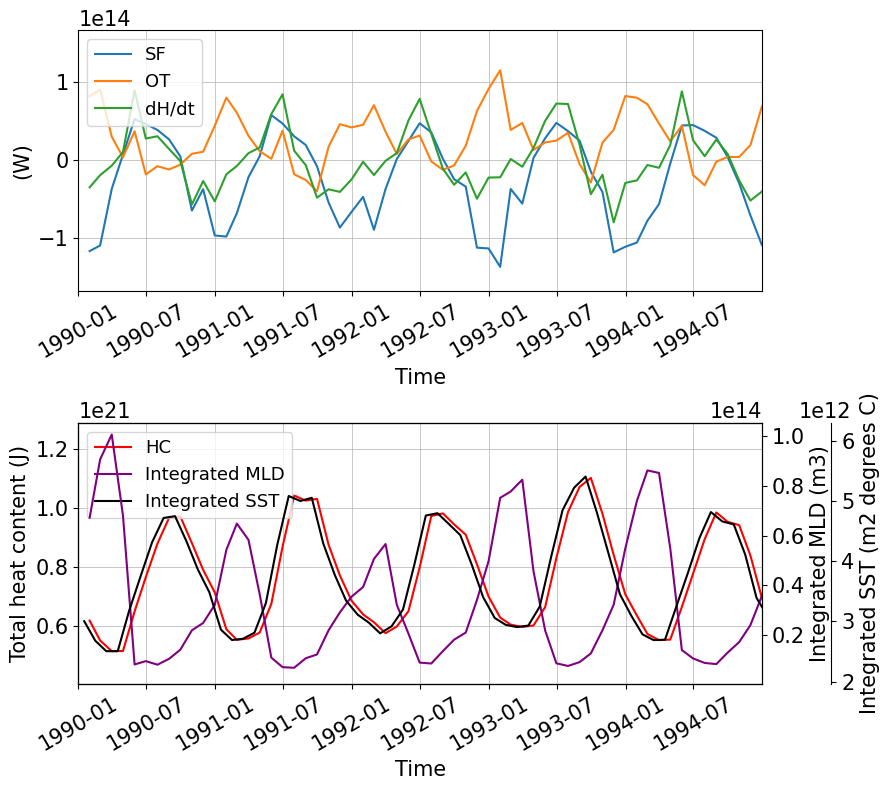

In [51]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(Q['time_counter'], Q, label = 'SF')
ax1.plot(advection['time_counter'], advection, label = 'OT')
ax1.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('(W)')
ax1.set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax1.grid(True, which='both', linewidth=0.5)
ax1.tick_params(axis = 'x', labelrotation = 30)

l1 = ax2.plot(HC['time_counter'],HC, label = 'HC', color = 'r')
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
l3 = ax4.plot(SSTs['time_counter'], SSTs, label = 'Integrated SST', color = 'k')

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')
ax2.set_ylabel('Total heat content (J)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SST (m2 degrees C)')
ax2.set_xlabel('Time')
ax2.set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax2.grid(True, which='both', linewidth=0.5)
ax2.tick_params(axis = 'x', labelrotation = 30)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 

plt.tight_layout()
plt.show()

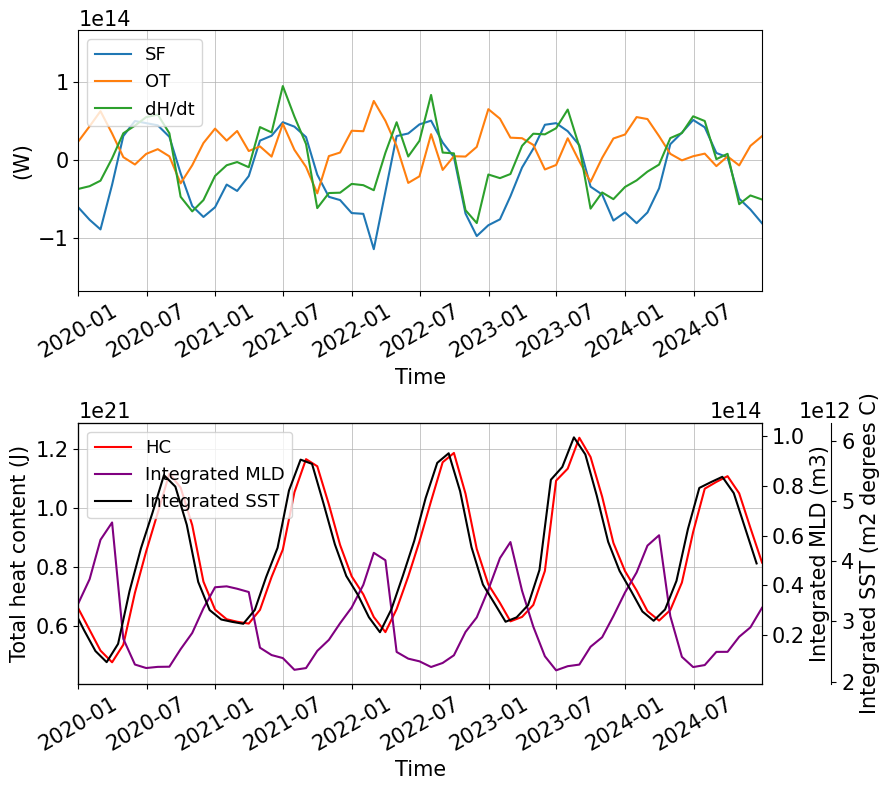

In [52]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(Q['time_counter'], Q, label = 'SF')
ax1.plot(advection['time_counter'], advection, label = 'OT')
ax1.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('(W)')
ax1.set_xlim(np.datetime64('2020-01-01'), np.datetime64('2024-12-31'))
ax1.grid(True, which='both', linewidth=0.5)
ax1.tick_params(axis = 'x', labelrotation = 30)

l1 = ax2.plot(HC['time_counter'],HC, label = 'HC', color = 'r')
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
l3 = ax4.plot(SSTs['time_counter'], SSTs, label = 'Integrated SST', color = 'k')

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='best')
ax2.set_ylabel('Total heat content (J)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SST (m2 degrees C)')
ax2.set_xlabel('Time')
ax2.set_xlim(np.datetime64('2020-01-01'), np.datetime64('2024-12-31'))
ax2.grid(True, which='both', linewidth=0.5)
ax2.tick_params(axis = 'x', labelrotation = 30)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 

plt.tight_layout()
plt.show()

(0.0, 5.0)

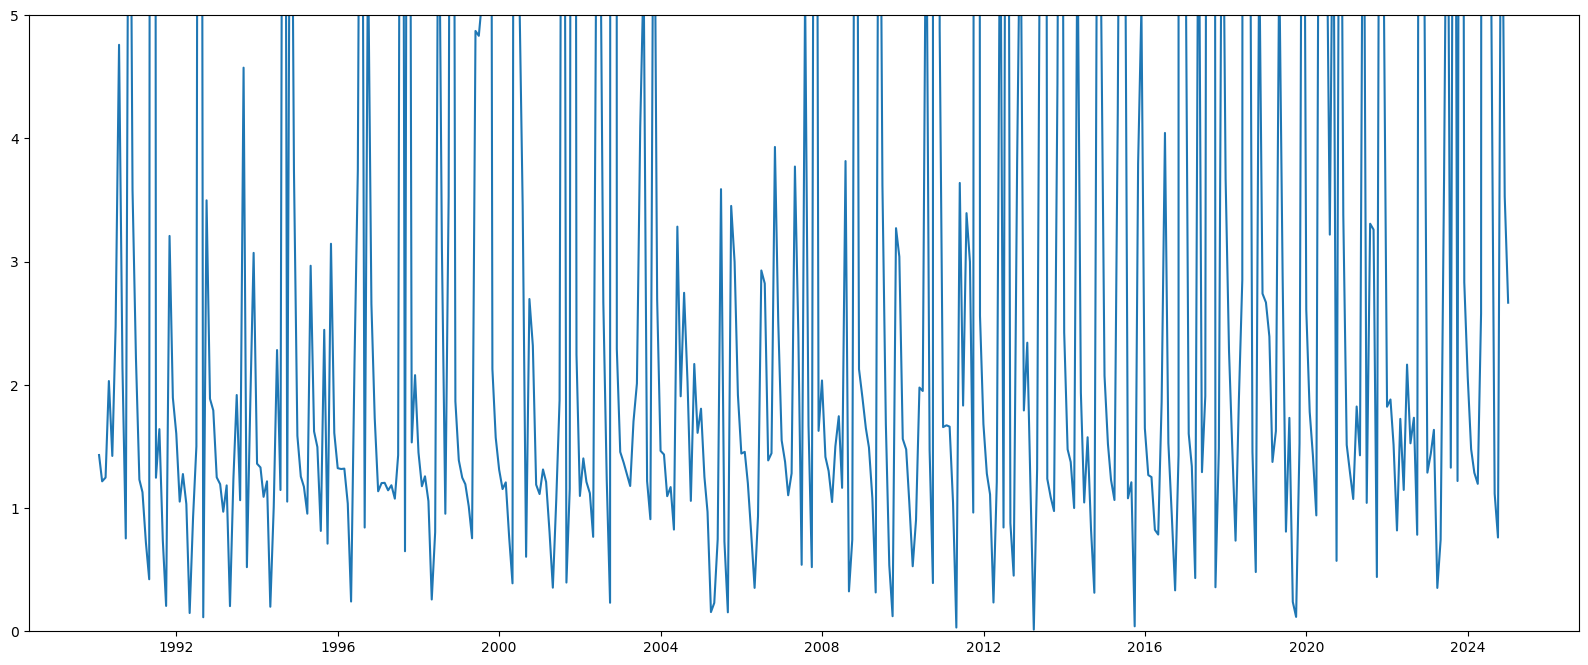

In [10]:
# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios['time_counter'], magnitude_ratios)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)


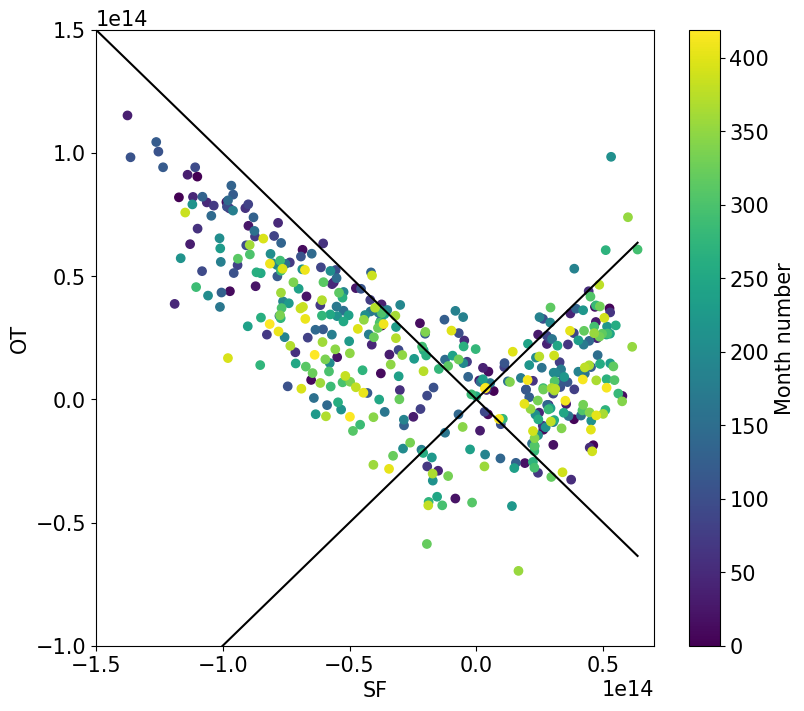

In [53]:
# Josey and Sinha Plot
progression = np.arange(len(Q.values))

fig, ax = plt.subplots(figsize = (9, 8))

plt.scatter(Q.values, advection.values, c = progression, cmap = 'viridis')
plt.xlabel('SF')
plt.ylabel('OT')

xmin = Q.min().item()
xmax = Q.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
ax.set_xlim(-1.5e14, 0.7e14)
ax.set_ylim(-1e14, 1.5e14)
plt.colorbar(ax = ax, label = ('Month number'))

plt.show()

In [13]:
## Annual Means 

Q_annual = Q.resample(time_counter = 'YE').mean()
advection_annual = advection.resample(time_counter = 'YE').mean()
dHbydt_annual = dHbydt.resample(time_counter = 'YE').mean()

Text(0, 0.5, '(W)')

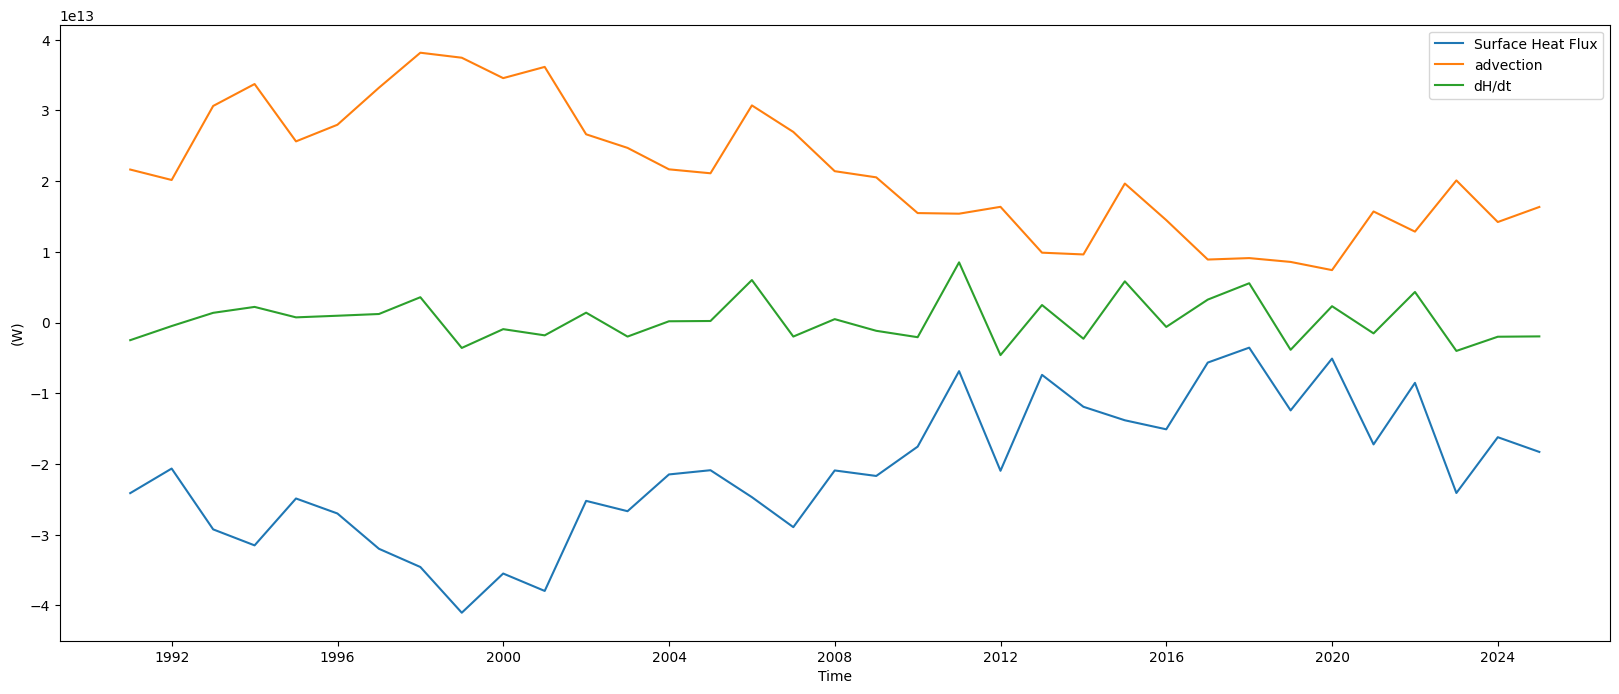

In [14]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (, 8))

ax.plot(Q_annual['time_counter'], Q_annual, label = 'Surface Heat Flux')
ax.plot(advection_annual['time_counter'], advection_annual, label = 'advection')
ax.plot(dHbydt_annual['time_counter'], dHbydt_annual, label = 'dH/dt')
ax.legend(loc = 'best')
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')

In [15]:
print(f'dHCbydt standard deviation: {(dHbydt.std(dim='time_counter')).values}')
print(f'Surface flux standard deviation: {(Q.std(dim='time_counter')).values}')
print(f'advection, entrainment, diffusion standard deviation: {(advection.std(dim='time_counter')).values}')

dHCbydt standard deviation: 42031053285391.805
Surface flux standard deviation: 51727266104050.19
advection, entrainment, diffusion standard deviation: 30812563445183.188


In [24]:
print('------1990-1995------')
print(f'dHCbydt standard deviation: {(dHbydt.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print(f'Surface flux standard deviation: {(Q.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print(f'advection, entrainment, diffusion standard deviation: {(advection.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print('------2020-2025------')
print(f'dHCbydt standard deviation: {(dHbydt.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')
print(f'Surface flux standard deviation: {(Q.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')
print(f'advection, entrainment, diffusion standard deviation: {(advection.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')

------1990-1995------
dHCbydt standard deviation: 3.874e+13
Surface flux standard deviation: 5.639e+13
advection, entrainment, diffusion standard deviation: 3.473e+13
------2020-2025------
dHCbydt standard deviation: 4.199e+13
Surface flux standard deviation: 4.953e+13
advection, entrainment, diffusion standard deviation: 2.491e+13
